# OCR pipeline after plate detection

## Цель
Построить baseline-пайплайн:
1. загрузка изображения;
2. детекция таблички;
3. вырезание таблички из исходного изображения;
4. OCR;
5. постобработка распознанного номера.

## Импорты

In [1]:
from pathlib import Path
import random
import re

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

from ultralytics import YOLO

## Пути

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATASET_DIR = PROJECT_ROOT / "dataset"
IMAGES_DIR = DATASET_DIR / "images"
MODEL_PATH = PROJECT_ROOT / "runs" / "detect" / "train4" / "weights" / "best.pt"

print("MODEL_PATH exists:", MODEL_PATH.exists())
print("TRAIN DIR exists:", (IMAGES_DIR / "train").exists())
print("VAL DIR exists:", (IMAGES_DIR / "val").exists())

MODEL_PATH exists: True
TRAIN DIR exists: True
VAL DIR exists: True


## Загрузка модели


In [3]:
model = YOLO(str(MODEL_PATH))
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

## Функции показа

In [4]:
def show_image(image, title="", figsize=(10, 8), cmap=None):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [5]:
def draw_bbox_on_image(image_rgb, bbox, title="Detection"):
    x1, y1, x2, y2 = map(int, bbox)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image_rgb)
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

## Сбор списка изображений

In [6]:
image_paths = []
for split in ["train", "val"]:
    split_dir = IMAGES_DIR / split
    image_paths.extend([
        p for p in split_dir.glob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])

print("Total images:", len(image_paths))

Total images: 123


## Выбор тестового изображения

TUL875_1.JPG


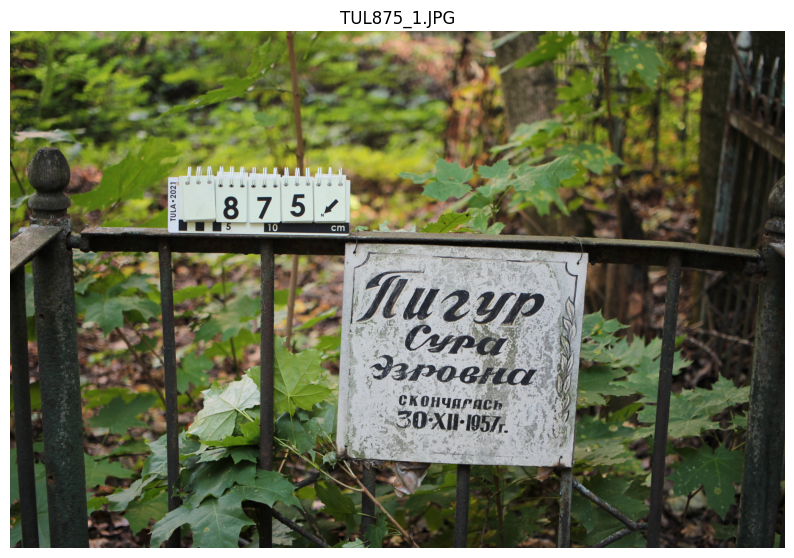

In [7]:
test_path = random.choice(image_paths)
print(test_path.name)

image_bgr = cv2.imread(str(test_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

show_image(image_rgb, title=test_path.name)

## Инференс модели на одном изображении

In [8]:
results = model(str(test_path), verbose=False)
result = results[0]

len(result.boxes)

1

## Лучший bbox

In [9]:
if len(result.boxes) == 0:
    print("Табличка не найдена")
else:
    boxes_xyxy = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()

    best_idx = np.argmax(confidences)

    best_bbox = boxes_xyxy[best_idx]
    best_conf = confidences[best_idx]

    print("Best confidence:", best_conf)
    print("Best bbox:", best_bbox)

Best confidence: 0.9629562
Best bbox: [     1038.8      887.43      2317.5      1398.4]


## Показ детекции

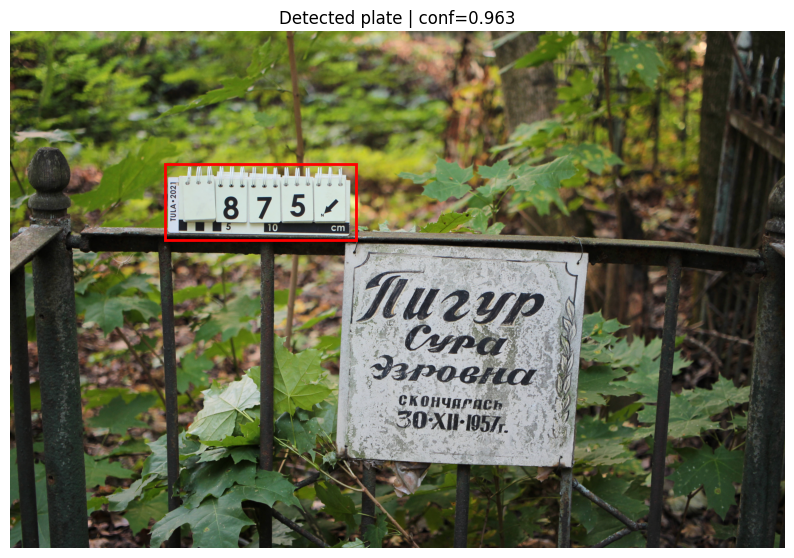

In [10]:
if len(result.boxes) > 0:
    draw_bbox_on_image(
        image_rgb,
        best_bbox,
        title=f"Detected plate | conf={best_conf:.3f}"
    )

## Вырезание таблички из исходного изображения

In [11]:
def crop_bbox(image_bgr, bbox):
    h, w = image_bgr.shape[:2]
    x1, y1, x2, y2 = map(int, bbox)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    return image_bgr[y1:y2, x1:x2]

Plate shape: (511, 1279, 3)


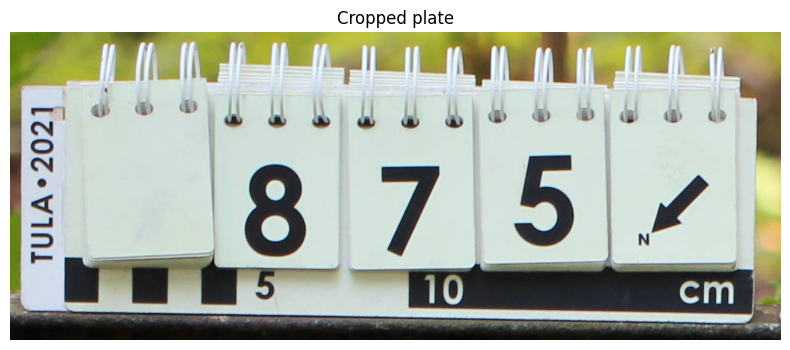

In [12]:
if len(result.boxes) > 0:
    plate_bgr = crop_bbox(image_bgr, best_bbox)
    plate_rgb = cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2RGB)

    print("Plate shape:", plate_bgr.shape)
    show_image(plate_rgb, title="Cropped plate", figsize=(10, 4))

## Нормализация ориентации

Если табличка выше, чем шире - повернем

In [13]:
def normalize_plate_orientation(image_bgr):
    h, w = image_bgr.shape[:2]
    if h > w:
        image_bgr = cv2.rotate(image_bgr, cv2.ROTATE_90_CLOCKWISE)
    return image_bgr

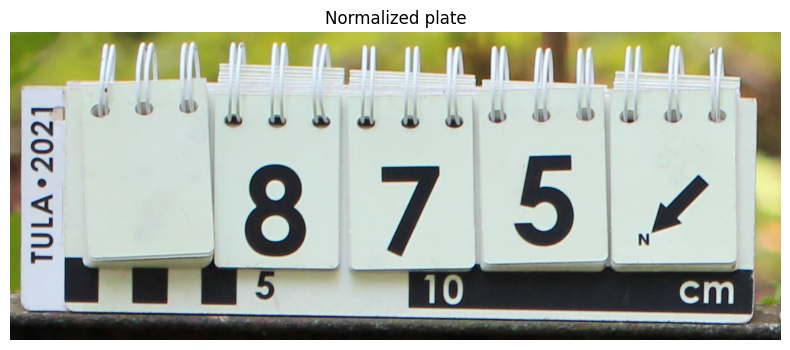

In [14]:
plate_bgr_norm = normalize_plate_orientation(plate_bgr)
plate_rgb_norm = cv2.cvtColor(plate_bgr_norm, cv2.COLOR_BGR2RGB)

show_image(plate_rgb_norm, title="Normalized plate", figsize=(10, 4))

## Подготовка под OCR

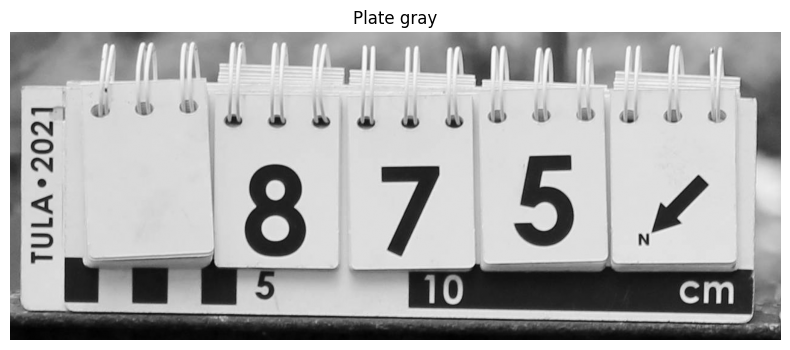

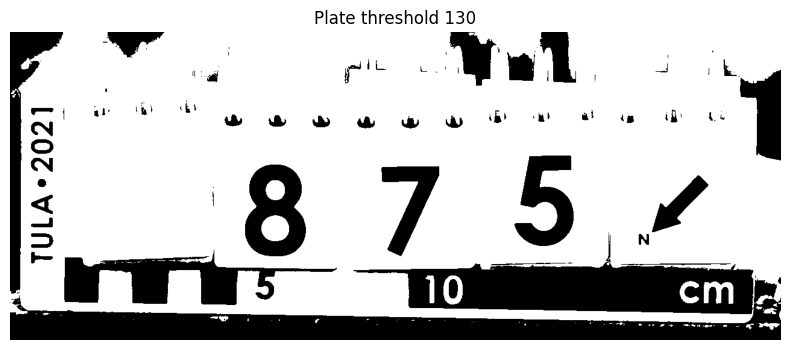

In [15]:
plate_gray = cv2.cvtColor(plate_bgr_norm, cv2.COLOR_BGR2GRAY)
_, plate_thresh = cv2.threshold(plate_gray, 130, 255, cv2.THRESH_BINARY)

show_image(plate_gray, title="Plate gray", figsize=(10, 4), cmap="gray")
show_image(plate_thresh, title="Plate threshold 130", figsize=(10, 4), cmap="gray")

## EasyOCR

In [16]:
import easyocr

## Создание OCR reader

In [17]:
reader = easyocr.Reader(['en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

## OCR на табличке

### plate_rgb_norm

In [18]:
ocr_results = reader.readtext(plate_rgb_norm)
ocr_results

d:\projects\plate-recognition\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[([[np.int32(28), np.int32(114)],
   [np.int32(80), np.int32(114)],
   [np.int32(80), np.int32(240)],
   [np.int32(28), np.int32(240)]],
  '8',
  np.float64(0.9817275610630851)),
 ([[np.int32(27), np.int32(256)],
   [np.int32(80), np.int32(256)],
   [np.int32(80), np.int32(391)],
   [np.int32(27), np.int32(391)]],
  '3',
  np.float64(0.48292424915743837)),
 ([[np.int32(606), np.int32(218)],
   [np.int32(734), np.int32(218)],
   [np.int32(734), np.int32(380)],
   [np.int32(606), np.int32(380)]],
  '7',
  np.float64(0.9999945163801982)),
 ([[np.int32(838), np.int32(202)],
   [np.int32(942), np.int32(202)],
   [np.int32(942), np.int32(354)],
   [np.int32(838), np.int32(354)]],
  '5',
  np.float64(0.9999995231628986)),
 ([[np.int32(403), np.int32(393)],
   [np.int32(443), np.int32(393)],
   [np.int32(443), np.int32(447)],
   [np.int32(403), np.int32(447)]],
  '5',
  np.float64(0.9999997615814351)),
 ([[np.int32(679), np.int32(397)],
   [np.int32(761), np.int32(397)],
   [np.int32(761), np.

### threshold

In [19]:
ocr_results_thresh = reader.readtext(plate_thresh)
ocr_results_thresh

[([[np.int32(204), np.int32(116)],
   [np.int32(242), np.int32(116)],
   [np.int32(242), np.int32(140)],
   [np.int32(204), np.int32(140)]],
  '161',
  np.float64(0.36984543908172557)),
 ([[np.int32(28), np.int32(114)],
   [np.int32(82), np.int32(114)],
   [np.int32(82), np.int32(240)],
   [np.int32(28), np.int32(240)]],
  '8',
  np.float64(0.9275528006597256)),
 ([[np.int32(26), np.int32(257)],
   [np.int32(80), np.int32(257)],
   [np.int32(80), np.int32(389)],
   [np.int32(26), np.int32(389)]],
  '3',
  np.float64(0.290814365407698)),
 ([[np.int32(361), np.int32(214)],
   [np.int32(758), np.int32(214)],
   [np.int32(758), np.int32(384)],
   [np.int32(361), np.int32(384)]],
  '8 7',
  np.float64(0.9242819965255589)),
 ([[np.int32(837), np.int32(207)],
   [np.int32(949), np.int32(207)],
   [np.int32(949), np.int32(357)],
   [np.int32(837), np.int32(357)]],
  '5',
  np.float64(1.0)),
 ([[np.int32(1054), np.int32(234)],
   [np.int32(1154), np.int32(234)],
   [np.int32(1154), np.int32(334

## Функция сборки текста

In [20]:
def extract_text_from_easyocr(ocr_output):
    texts = []
    confs = []

    for item in ocr_output:
        bbox, text, conf = item
        texts.append(text)
        confs.append(conf)

    merged_text = " ".join(texts)
    mean_conf = float(np.mean(confs)) if confs else 0.0

    return merged_text, mean_conf

In [21]:
raw_text, raw_conf = extract_text_from_easyocr(ocr_results)
raw_text_thresh, raw_conf_thresh = extract_text_from_easyocr(ocr_results_thresh)

print("RGB OCR:", repr(raw_text), raw_conf)
print("THRESH OCR:", repr(raw_text_thresh), raw_conf_thresh)

RGB OCR: '8 3 7 5 5 10 cm' 0.9199943199052926
THRESH OCR: '161 8 3 8 7 5 Y TTZ 10 cm' 0.6606348625789253


## Постобработка текста

In [22]:
def clean_recognized_plate(text: str) -> str:
    text = text.lower()
    text = text.replace(" ", "")
    
    # оставляем только цифры и буквы a-e
    text = re.sub(r"[^0-9abcde]", "", text)

    # ищем шаблон: 1-4 цифры + опциональная буква
    match = re.search(r"\d{1,4}[abcde]?", text)
    return match.group(0) if match else ""

In [23]:
clean_rgb = clean_recognized_plate(raw_text)
clean_thresh = clean_recognized_plate(raw_text_thresh)

print("CLEAN RGB:", repr(clean_rgb))
print("CLEAN THRESH:", repr(clean_thresh))

CLEAN RGB: '8375'
CLEAN THRESH: '1618'


## Нормализация номера

In [24]:
def normalize_plate_number(text: str) -> str:
    match = re.fullmatch(r"(\d{1,4})([abcde]?)", text)
    if not match:
        return ""

    digits, suffix = match.groups()
    digits = digits.zfill(4)
    return digits + suffix

In [25]:
norm_rgb = normalize_plate_number(clean_rgb)
norm_thresh = normalize_plate_number(clean_thresh)

print("NORMALIZED RGB:", repr(norm_rgb))
print("NORMALIZED THRESH:", repr(norm_thresh))

NORMALIZED RGB: '8375'
NORMALIZED THRESH: '1618'


## Результат первой попытки

EasyOCR читает не только номер, а ещё:

- левую вертикальную надпись `TULA 2021`
- нижнюю шкалу `5, 10`
- `cm`
- стрелку / лишние символы

Поэтому:

- RGB OCR: '8 3 7 5 5 10 cm'
- модель взяла лишние символы
- в постобработке получилось 8375, а правильный номер тут, судя по фото, 875

То есть проблема уже не в детекции, а в том, что OCR подаётся на слишком большую область.

## Функция выделения зоны номера

In [34]:
def extract_number_zone(plate_bgr):
    h, w = plate_bgr.shape[:2]

    x1 = int(w * 0.06)   # убираем левую подпись
    x2 = int(w * 0.84)   # убираем правую стрелку
    y1 = int(h * 0.18)   # немного сверху отступ
    y2 = int(h * 0.78)   # убираем нижнюю шкалу

    return plate_bgr[y1:y2, x1:x2]

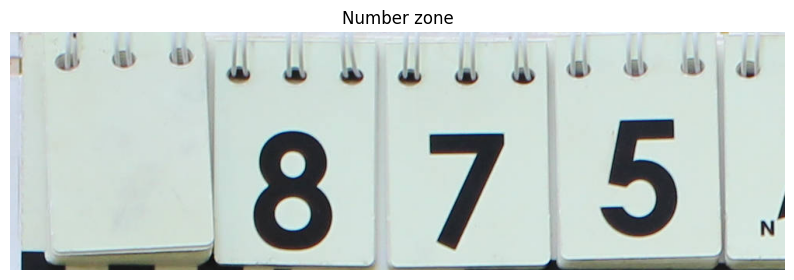

In [35]:
number_zone_bgr = extract_number_zone(plate_bgr_norm)
number_zone_rgb = cv2.cvtColor(number_zone_bgr, cv2.COLOR_BGR2RGB)

show_image(number_zone_rgb, title="Number zone", figsize=(10, 4))

## Подготовка number zone

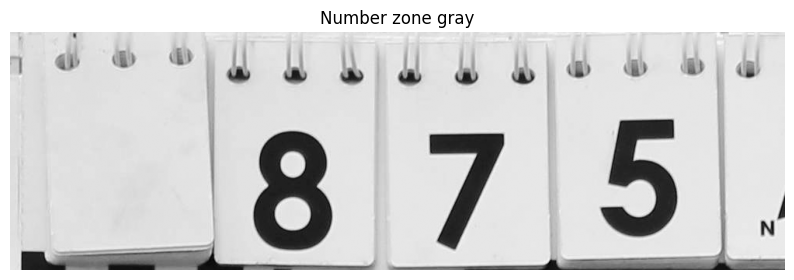

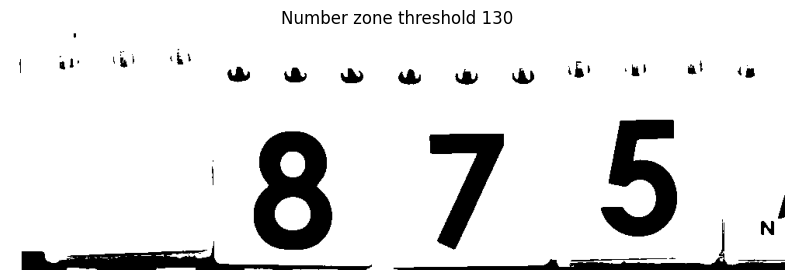

In [36]:
number_gray = cv2.cvtColor(number_zone_bgr, cv2.COLOR_BGR2GRAY)
_, number_thresh = cv2.threshold(number_gray, 130, 255, cv2.THRESH_BINARY)

show_image(number_gray, title="Number zone gray", figsize=(10, 4), cmap="gray")
show_image(number_thresh, title="Number zone threshold 130", figsize=(10, 4), cmap="gray")

## Проверка OCR на выбранной зоне

In [37]:
ocr_number_rgb = reader.readtext(number_zone_rgb)
ocr_number_thresh = reader.readtext(number_thresh)

print("OCR number RGB:", ocr_number_rgb)
print("OCR number THRESH:", ocr_number_thresh)

OCR number RGB: [([[np.int32(526), np.int32(126)], [np.int32(654), np.int32(126)], [np.int32(654), np.int32(282)], [np.int32(526), np.int32(282)]], '7', np.float64(0.9536378743314112)), ([[np.int32(762), np.int32(110)], [np.int32(866), np.int32(110)], [np.int32(866), np.int32(262)], [np.int32(762), np.int32(262)]], '5', np.float64(0.9999994039536411))]
OCR number THRESH: [([[np.int32(299), np.int32(119)], [np.int32(682), np.int32(119)], [np.int32(682), np.int32(288)], [np.int32(299), np.int32(288)]], '8 7', np.float64(0.9934052377162074)), ([[np.int32(759), np.int32(115)], [np.int32(869), np.int32(115)], [np.int32(869), np.int32(267)], [np.int32(759), np.int32(267)]], '5', np.float64(1.0))]


In [38]:
raw_number_rgb, conf_number_rgb = extract_text_from_easyocr(ocr_number_rgb)
raw_number_thresh, conf_number_thresh = extract_text_from_easyocr(ocr_number_thresh)

print("RAW NUMBER RGB:", repr(raw_number_rgb), conf_number_rgb)
print("RAW NUMBER THRESH:", repr(raw_number_thresh), conf_number_thresh)

RAW NUMBER RGB: '7 5' 0.9768186391425262
RAW NUMBER THRESH: '8 7 5' 0.9967026188581036


## Постобработка

In [44]:
def process_ocr_text(raw_text: str) -> str:
    text = raw_text.lower()
    text = re.sub(r"[^0-9abcde]", "", text)

    match = re.fullmatch(r"\d{1,4}[abcde]?", text)
    return match.group(0) if match else ""

## Выбор лучшего кандидата

In [45]:
clean_rgb = process_ocr_text(raw_number_rgb)
clean_thresh = process_ocr_text(raw_number_thresh)

# выбираем лучший
if len(clean_thresh) >= len(clean_rgb):
    final_text = clean_thresh
    final_conf = conf_number_thresh
else:
    final_text = clean_rgb
    final_conf = conf_number_rgb

print("FINAL:", final_text, final_conf)

FINAL: 875 0.9967026188581036


## Нормализация

In [46]:
final_norm = normalize_plate_number(final_text)
print("NORMALIZED FINAL:", final_norm)

NORMALIZED FINAL: 0875


## Результат OCR на одном изображении

После выделения не всей таблички, а только центральной зоны с номером качество OCR заметно улучшилось.

Наблюдения:
- OCR на всей табличке распознавал лишние элементы:
  - вертикальную подпись слева;
  - нижнюю шкалу;
  - обозначение `cm`;
  - стрелку.
- После выделения `number zone` распознавание стало значительно точнее.
- На текущем примере корректный результат был получен на бинаризованном изображении (`threshold = 130`).

Итог:
- raw OCR: `8 7 5`
- cleaned OCR: `875`
- normalized OCR: `0875`

Вывод:
для OCR необходимо использовать не всю табличку целиком, а предварительно выделенную зону номера. Это уменьшает влияние служебных элементов и повышает качество распознавания.

## Функция извлечения эталона из имени файла

In [47]:
def extract_expected_number_from_filename(filename: str) -> str:
    stem = Path(filename).stem.lower()

    match = re.search(r"(\d{1,4}[abcde]?)", stem)
    if not match:
        return ""

    raw = match.group(1)
    return normalize_plate_number(raw)

In [48]:
examples = [
    "MDZ087 _5.jpg",
    "TUL855 _9.jpg",
    "123a.jpg",
    "7.jpg"
]

for name in examples:
    print(name, "->", extract_expected_number_from_filename(name))

MDZ087 _5.jpg -> 0087
TUL855 _9.jpg -> 0855
123a.jpg -> 0123a
7.jpg -> 0007


## Функция полного pipeline для одного изображения

In [49]:
def run_ocr_pipeline_on_image(image_path: Path, model, reader):
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    results = model(str(image_path), verbose=False)
    result = results[0]

    if len(result.boxes) == 0:
        return {
            "filename": image_path.name,
            "detected": False,
            "det_conf": 0.0,
            "ocr_conf": 0.0,
            "raw_text": "",
            "clean_text": "",
            "normalized_text": "",
        }

    boxes_xyxy = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()

    best_idx = np.argmax(confidences)
    best_bbox = boxes_xyxy[best_idx]
    best_conf = float(confidences[best_idx])

    plate_bgr = crop_bbox(image_bgr, best_bbox)
    plate_bgr_norm = normalize_plate_orientation(plate_bgr)

    number_zone_bgr = extract_number_zone(plate_bgr_norm)
    number_zone_gray = cv2.cvtColor(number_zone_bgr, cv2.COLOR_BGR2GRAY)
    _, number_zone_thresh = cv2.threshold(number_zone_gray, 130, 255, cv2.THRESH_BINARY)

    ocr_output = reader.readtext(number_zone_thresh)
    raw_text, ocr_conf = extract_text_from_easyocr(ocr_output)

    clean_text = process_ocr_text(raw_text)
    normalized_text = normalize_plate_number(clean_text)

    return {
        "filename": image_path.name,
        "detected": True,
        "det_conf": best_conf,
        "ocr_conf": ocr_conf,
        "raw_text": raw_text,
        "clean_text": clean_text,
        "normalized_text": normalized_text,
    }

## Сбор небольшой выборки

In [50]:
sample_paths = random.sample(image_paths, min(15, len(image_paths)))
[len(sample_paths), sample_paths[:3]]

[15,
 [WindowsPath('D:/projects/plate-recognition/dataset/images/train/TUL831_4.jpg'),
  WindowsPath('D:/projects/plate-recognition/dataset/images/train/MDZ095 _2.jpg'),
  WindowsPath('D:/projects/plate-recognition/dataset/images/train/SDB2024.jpg')]]

## Проверка pipeline

In [51]:
rows = []

for path in sample_paths:
    result_row = run_ocr_pipeline_on_image(path, model, reader)

    expected = extract_expected_number_from_filename(path.name)
    predicted = result_row["normalized_text"]

    result_row["expected_text"] = expected
    result_row["match"] = expected == predicted if expected and predicted else False

    rows.append(result_row)

df_results = pd.DataFrame(rows)
df_results

,filename,detected,det_conf,ocr_conf,raw_text,clean_text,normalized_text,expected_text,match
0,TUL831_4.jpg,True,0.988873,0.999955,3,3,0003,0831,False
1,MDZ095 _2.jpg,True,0.863263,0.994958,9 5,95,0095,0095,True
2,SDB2024.jpg,True,0.932975,0.935252,2 0/214,,,2024,False
3,MDZ100.jpg,True,0.968368,0.000000,,,,0100,False
4,SDB1034.jpg,True,0.932956,0.517425,"3 , T4] 1 ""o",341,0341,1034,False
5,TUL879_3.JPG,True,0.975963,0.630702,1 W 4 8 7 9 2: nAs 10,,,0879,False
6,SDB281.jpg,True,0.929592,0.723313,0 218 ' 1,,,0281,False
7,MDZ087 _6.jpg,True,0.764526,0.991541,8,8,0008,0087,False
8,TUL878.JPG,True,0.821463,0.985166,8 7 8,878,0878,0878,True
9,TUL886_3.JPG,True,0.957692,0.478470,3 { 8 8 6,3886,3886,0886,False


In [52]:
df_results[["filename", "expected_text", "normalized_text", "match", "det_conf", "ocr_conf"]]

match_rate = df_results["match"].mean()
print("Match rate:", match_rate)

Match rate: 0.26666666666666666


In [53]:
df_errors = df_results[df_results["match"] == False].copy()
df_errors[["filename", "expected_text", "raw_text", "clean_text", "normalized_text", "det_conf", "ocr_conf"]]

,filename,expected_text,raw_text,clean_text,normalized_text,det_conf,ocr_conf
0,TUL831_4.jpg,0831,3,3,0003,0.988873,0.999955
2,SDB2024.jpg,2024,2 0/214,,,0.932975,0.935252
3,MDZ100.jpg,0100,,,,0.968368,0.000000
4,SDB1034.jpg,1034,"3 , T4] 1 ""o",341,0341,0.932956,0.517425
5,TUL879_3.JPG,0879,1 W 4 8 7 9 2: nAs 10,,,0.975963,0.630702
6,SDB281.jpg,0281,0 218 ' 1,,,0.929592,0.723313
7,MDZ087 _6.jpg,0087,8,8,0008,0.764526,0.991541
9,TUL886_3.JPG,0886,3 { 8 8 6,3886,3886,0.957692,0.478470
10,SDB1035.jpg,1035,8 1/0 3 5 J5 1,,,0.926573,0.636713
11,MDZ168_3.jpg,0168,,,,0.904274,0.000000


## Проверка OCR pipeline на выборке изображений

Pipeline был протестирован на случайной выборке из 15 изображений.

### Общий результат

- Доля правильных совпадений (match rate): **0.27**
- Детекция таблички отработала стабильно (во всех случаях `detected = True`)
- Основные ошибки связаны не с детекцией, а с OCR

---

### Наблюдения

#### 1. Детекция работает хорошо
- Во всех примерах табличка была найдена
- Значения `det_conf` в большинстве случаев высокие (> 0.8)
- Ошибки практически полностью относятся к этапу OCR

---

#### 2. OCR работает нестабильно

Основные типы ошибок:

**а) Потеря части цифр**
- `0831 → 3`
- `0087 → 8`
- `0096 → 6`

Причина: OCR видит только часть номера

---

**б) Шум и лишние символы**
- `3 , T4] 1 "o → 341`
- `1 W  4 8 7 9 2: nAs 10 → ""`

Причина: в область OCR попадают лишние элементы (шкала, подписи, артефакты)

---

**в) Полный провал OCR**
- `raw_text = ""`, `ocr_conf = 0.0`

Причина: либо плохое качество зоны, либо неудачная бинаризация

---

**г) Смешивание символов**
- `2 0/214` вместо `2024`
- `3 { 8 8 6 → 3886`

---

#### 3. Threshold работает лучше RGB
- В большинстве успешных случаев правильный результат получен через `threshold`
- RGB чаще даёт лишние символы

---

### Примеры успешных кейсов

| Файл        | OCR | Итог |
|------------|-----|------|
| TUL878.JPG | 878 | ✔ |
| TUL884_1   | 884 | ✔ |
| TUL865_1   | 865 | ✔ |
| MDZ095 _2  | 95  | ✔ |

---

### Примеры ошибок

| Файл        | Ожидалось | Получено |
|------------|----------|----------|
| TUL831_4   | 0831     | 0003     |
| SDB1034    | 1034     | 0341     |
| MDZ087 _6  | 0087     | 0008     |

---

### Выводы

1. **Детекция решена** — модель уверенно находит таблички  
2. Основная проблема — **OCR и подготовка изображения**  
3. Текущий pipeline:
   - чувствителен к шуму  
   - иногда теряет цифры  
   - иногда добавляет лишние  

---

### Что нужно улучшить

Следующие шаги для улучшения качества:

- улучшить выделение зоны номера (crop точнее)
- попробовать другие методы предобработки:
  - adaptive threshold
  - морфология
- сортировать OCR по координате X (слева направо)
- использовать альтернативный OCR (например, PaddleOCR)
- добавить fallback-логику:
  - если OCR плохой → пробовать другую предобработку

---

### Итог

Pipeline уже работает end-to-end:
- изображение → детекция → OCR → номер

Но качество OCR пока недостаточно для автоматического переименования без проверки.

Следующий этап — повышение точности OCR.

## Итог этапа OCR baseline

На данном этапе был собран baseline pipeline:
- детекция таблички с помощью YOLO;
- вырезание таблички из исходного изображения;
- выделение зоны номера;
- OCR с помощью EasyOCR;
- очистка и нормализация результата.

Результаты показали, что:
- детекция таблички работает надёжно;
- основной источник ошибок находится на этапе OCR;
- текущий baseline OCR недостаточно точен для полностью автоматического переименования файлов.

Вывод:
следующий этап работы должен быть направлен на улучшение OCR и предобработки зоны номера.